In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
train_df = pd.read_csv("data/train.csv")

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 56 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Id                                  15120 non-null  int64
 1   Elevation                           15120 non-null  int64
 2   Aspect                              15120 non-null  int64
 3   Slope                               15120 non-null  int64
 4   Horizontal_Distance_To_Hydrology    15120 non-null  int64
 5   Vertical_Distance_To_Hydrology      15120 non-null  int64
 6   Horizontal_Distance_To_Roadways     15120 non-null  int64
 7   Hillshade_9am                       15120 non-null  int64
 8   Hillshade_Noon                      15120 non-null  int64
 9   Hillshade_3pm                       15120 non-null  int64
 10  Horizontal_Distance_To_Fire_Points  15120 non-null  int64
 11  Wilderness_Area1                    15120 non-null  int64
 12  Wild

In [8]:
train_df.drop(columns=['Id'], inplace=True)

X = train_df.drop(columns=['Cover_Type'])
y = train_df['Cover_Type']

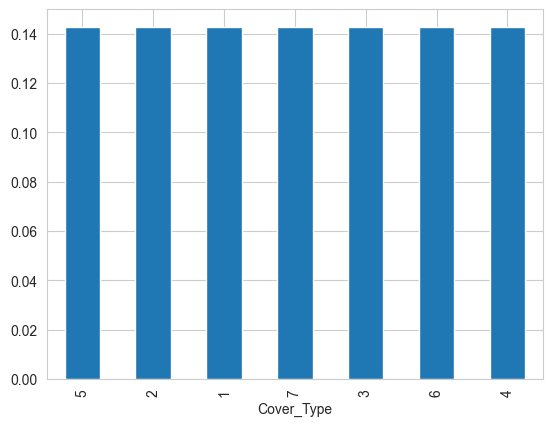

In [13]:
y.value_counts(normalize=True).plot(kind='bar');

In [14]:
X.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40
count,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,...,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000
mean,2749.322553,156.676653,16.501587,227.195701,51.076521,1714.023214,212.704299,218.965608,135.091997,1511.147288,...,0.021958,0.045635,0.040741,0.001455,0.006746,0.000661,0.002249,0.048148,0.043452,0.030357
std,417.678187,110.085801,8.453927,210.075296,61.239406,1325.066358,30.561287,22.801966,45.895189,1099.936493,...,0.146550,0.208699,0.197696,0.038118,0.081859,0.025710,0.047368,0.214086,0.203880,0.171574
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2376.000000,65.000000,10.000000,67.000000,5.000000,764.000000,196.000000,207.000000,106.000000,730.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2752.000000,126.000000,15.000000,180.000000,32.000000,1316.000000,220.000000,223.000000,138.000000,1256.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3104.000000,261.000000,22.000000,330.000000,79.000000,2270.000000,235.000000,235.000000,167.000000,1988.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3849.000000,360.000000,52.000000,1343.000000,554.000000,6890.000000,254.000000,254.000000,248.000000,6993.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
print(train_df.isnull().sum())

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


In [ ]:
train_df.hist(figsize=(10,10), bins=30)
plt.tight_layout()
plt.show();

In [ ]:
X.corr()

plt.figure(figsize=(20,20))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show();

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

In [25]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [32]:
model = CatBoostClassifier(
    iterations=10000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=200
)

In [33]:
model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 0.6111938	test: 0.6081349	best: 0.6081349 (0)	total: 5.47ms	remaining: 54.7s
200:	learn: 0.8435020	test: 0.8098545	best: 0.8098545 (189)	total: 697ms	remaining: 34s
400:	learn: 0.8906250	test: 0.8399471	best: 0.8409392 (398)	total: 1.38s	remaining: 33s
600:	learn: 0.9187335	test: 0.8541667	best: 0.8541667 (587)	total: 2.05s	remaining: 32.1s
800:	learn: 0.9376653	test: 0.8627646	best: 0.8634259 (789)	total: 2.75s	remaining: 31.6s
1000:	learn: 0.9519676	test: 0.8683862	best: 0.8693783 (976)	total: 3.46s	remaining: 31.1s
1200:	learn: 0.9637070	test: 0.8740079	best: 0.8756614 (1180)	total: 4.17s	remaining: 30.5s
1400:	learn: 0.9714782	test: 0.8763228	best: 0.8776455 (1387)	total: 4.89s	remaining: 30s
1600:	learn: 0.9794974	test: 0.8776455	best: 0.8789683 (1473)	total: 5.59s	remaining: 29.4s
1800:	learn: 0.9855324	test: 0.8789683	best: 0.8799603 (1753)	total: 6.41s	remaining: 29.2s
2000:	learn: 0.9900794	test: 0.8796296	best: 0.8806217 (1917)	total: 7.26s	remaining: 29s
2200:	lear